# gemini-3.6-flash — 암시적(implicit) KV 캐시 벤치마크

**대상 모델**: `gemini-3.6-flash`
**측정 항목**: 캐시 MISS vs HIT 의 **TTFT**, **전체 latency**, **cached_content_token_count**, **비용**

## Gemini 암시적 캐싱이란 — 3사 비교

| | OpenAI (GPT) | Anthropic (Claude) | **Gemini (암시적)** |
|---|---|---|---|
| 켜는 방식 | 자동 | 명시적 `cache_control` | **자동** (끌 수 없음) |
| 쓰기 비용 | 없음 | 1.25배 | **없음** |
| 읽기 할인 | 입력가의 ~10% | 입력가의 10% | 입력가의 ~10% |
| usage 필드 | `cached_tokens` | `cache_creation_/cache_read_input_tokens` | `cached_content_token_count` |
| 히트 조건 | 프리픽스 바이트 일치 | `cache_control` 지점까지 일치 | 프리픽스 일치 + **최소 토큰** |

Gemini 에는 두 가지 캐싱이 있습니다.
- **명시적 캐싱** (`client.caches.create`) — 개발자가 캐시 객체를 만들고 TTL·스토리지 비용을 직접 부담. 히트가 **보장**됨.
- **암시적 캐싱** — 이 노트북의 주제. 아무 설정 없이 **자동**으로 적용되고 히트하면 자동 할인. 다만 **보장되지 않습니다**.

## 이 노트북의 관전 포인트 — "보장되지 않는다"가 실제로 어떻게 나타나는가
사전 프로브에서 동일 프리픽스로 4회 연속 호출했을 때:

```
call1: cached=None   ← 미스
call2: cached=None   ← 미스 (동일 프리픽스인데도!)
call3: cached=None   ← 미스
call4: cached=8168 / prompt=10806  ← 76% 만 적중
```

즉 암시적 캐싱은 ① **적중까지 워밍업 회차가 필요**하고 ② 적중해도 **부분 캐싱**(전량이 아님)입니다.
GPT/Claude 가 2회차부터 거의 전량 적중하는 것과 대비됩니다. 아래에서 이 두 특성을 직접 측정합니다.

> ⚠️ 암시적 캐싱은 **보장되지 않으므로** 실행할 때마다 히트 회차와 적중률이 달라질 수 있습니다.
> 히트가 아예 안 나오면 `N_WARMUP` 을 늘리거나 `TARGET_TOKENS` 를 키워 재실행하세요.
>
> ⚠️ **무료 티어는 이 모델이 분당 5회로 제한**됩니다(실측 확인). 이 노트북은 총 10회를 호출하므로
> 스로틀링 셀이 호출 간격을 자동으로 벌립니다 — 그래서 전체 실행에 **2~3분** 걸립니다.
> 유료 티어라면 `RPM_LIMIT` 을 실제 한도로 올려 대기를 줄이세요.


In [1]:
# === 셋업 & 실험 설정 ===
import json, os, pathlib, re, statistics, time, uuid

from google import genai
from google.genai import types

try:
    from dotenv import load_dotenv
    load_dotenv()  # 프로젝트 루트 .env 의 GOOGLE_API_KEY 로드
except Exception:
    pass

assert os.environ.get("GOOGLE_API_KEY") or os.environ.get("GEMINI_API_KEY"), \
    ".env 에 GOOGLE_API_KEY 를 설정해주세요"
client = genai.Client()

# ------- 조절 가능한 설정 -------
MODEL             = "gemini-3.6-flash"
TARGET_TOKENS     = 20_000     # 컨텍스트 목표 크기
MAX_OUTPUT_TOKENS = 32         # 출력 짧게 고정 → prefill 캐싱 효과에 집중
N_REPEAT          = 3          # MISS / HIT 각각 반복 횟수
N_WARMUP          = 4          # 암시적 캐시 적재용 워밍업 (GPT/Claude 보다 많이 필요)

# ------- 레이트 리밋 -------
# ⚠️ 무료 티어는 이 모델이 **분당 5회**로 제한됩니다. 이 노트북은 총 N_WARMUP + 2*N_REPEAT 회를
#    호출하므로 스로틀링 없이 돌리면 429(RESOURCE_EXHAUSTED)가 납니다.
#    유료 티어라면 RPM_LIMIT 을 실제 한도로 올려 대기 시간을 줄이세요 (None 이면 스로틀링 없음).
RPM_LIMIT = 5

# ------- 단가 ($ / 1M tokens) -------
# ⚠️ gemini-3.6-flash 단가는 이 노트북 작성 시점에 미확인입니다. 플레이스홀더이므로
#    Google AI 공식 pricing 으로 교체하세요. 시간 측정 결과는 단가와 무관합니다.
PRICE_INPUT        = 0.30    # ⚠️ 미확인 — 플레이스홀더
PRICE_CACHED_INPUT = 0.03    # ⚠️ 미확인 — 통상 입력가의 10% 가정
PRICE_OUTPUT       = 2.50    # ⚠️ 미확인 — 플레이스홀더


def calc_cost(prompt_tokens, cached, output_tokens):
    uncached = (prompt_tokens or 0) - (cached or 0)
    return (uncached * PRICE_INPUT
            + (cached or 0) * PRICE_CACHED_INPUT
            + (output_tokens or 0) * PRICE_OUTPUT) / 1_000_000


print(f"모델: {MODEL} | 목표 토큰: {TARGET_TOKENS:,} | 반복: {N_REPEAT} | 워밍업: {N_WARMUP}")
print(f"단가($/1M): in {PRICE_INPUT} | cached-in {PRICE_CACHED_INPUT} | out {PRICE_OUTPUT}")

모델: gemini-3.6-flash | 목표 토큰: 20,000 | 반복: 3 | 워밍업: 4
단가($/1M): in 0.3 | cached-in 0.03 | out 2.5


In [2]:
# === 합성 컨텍스트 생성 (count_tokens 로 실측하며 목표까지 적재) ===
UNIT = (
    "The distributed order-processing service uses idempotency keys and an inbox table to guarantee "
    "that redelivered messages do not duplicate side effects. Under at-least-once delivery the consumer "
    "must be idempotent: derive the key from the message id and insert it in the same transaction that "
    "applies the effect, so the unique constraint short-circuits duplicates on redelivery. "
)

QUESTION = "\n\nSummarize the single most important rule above in one sentence."


def build_prefix(target_tokens):
    """목표 토큰에 근접할 때까지 UNIT 을 반복하고 실측 토큰 수를 반환."""
    per_unit = client.models.count_tokens(model=MODEL, contents=UNIT).total_tokens
    n = max(1, target_tokens // per_unit)
    text = UNIT * n
    total = client.models.count_tokens(model=MODEL, contents=text).total_tokens
    return text, total


PREFIX, PREFIX_TOKENS = build_prefix(TARGET_TOKENS)
print(f"프리픽스 실측 토큰: {PREFIX_TOKENS:,} (목표 {TARGET_TOKENS:,})")

프리픽스 실측 토큰: 19,442 (목표 20,000)


In [3]:
# === 레이트 리밋 스로틀 + 429 재시도 ===
# 무료 티어(분당 5회)에서도 벤치가 끝까지 돌도록 호출 간격을 벌리고, 그래도 429 가 나면
# 서버가 알려준 retryDelay 만큼 기다렸다가 재시도합니다.
# ⚠️ 대기 시간은 TTFT/latency 측정 구간 **밖**에서 소비되므로 측정값을 오염시키지 않습니다.
_last_call = [0.0]
MIN_INTERVAL = (60.0 / RPM_LIMIT + 1.0) if RPM_LIMIT else 0.0


def _throttle():
    if not MIN_INTERVAL or not _last_call[0]:
        return
    wait = MIN_INTERVAL - (time.monotonic() - _last_call[0])
    if wait > 0:
        print(f"    (레이트 리밋 대기 {wait:.0f}s)")
        time.sleep(wait)


def _retry_delay_from(err) -> float:
    """429 응답의 retryDelay(예: '22s')를 초로 파싱. 못 찾으면 기본 30초."""
    text = str(err)
    m = re.search(r"'retryDelay':\s*'(\d+(?:\.\d+)?)s'", text)
    if m:
        return float(m.group(1)) + 2.0
    m = re.search(r"retry in (\d+(?:\.\d+)?)s", text)
    return float(m.group(1)) + 2.0 if m else 30.0


def with_retry(fn, *, max_tries=4):
    for attempt in range(1, max_tries + 1):
        _throttle()
        try:
            out = fn()
            _last_call[0] = time.monotonic()
            return out
        except Exception as e:
            _last_call[0] = time.monotonic()
            if "429" not in str(e) and "RESOURCE_EXHAUSTED" not in str(e):
                raise
            if attempt == max_tries:
                raise
            d = _retry_delay_from(e)
            print(f"    (429 — {d:.0f}s 대기 후 재시도 {attempt}/{max_tries - 1})")
            time.sleep(d)


print(f"스로틀: RPM_LIMIT={RPM_LIMIT} → 호출 간 최소 {MIN_INTERVAL:.0f}s 간격")
print(f"총 예정 호출 수: {N_WARMUP + 2 * N_REPEAT}회 "
      f"(예상 대기 시간 ≈ {(N_WARMUP + 2 * N_REPEAT - 1) * MIN_INTERVAL / 60:.1f}분)")

스로틀: RPM_LIMIT=5 → 호출 간 최소 13s 간격
총 예정 호출 수: 10회 (예상 대기 시간 ≈ 1.9분)


In [4]:
# === 측정 유틸: 스트리밍으로 TTFT + 전체 latency + cached_content_token_count ===
def timed_call(*, unique: bool):
    """unique=True → 맨 앞에 nonce 삽입해 프리픽스를 매번 바꿔 MISS 강제 / False → 동일 프리픽스로 HIT 유도."""
    text = PREFIX
    if unique:
        text = f"[nonce-{uuid.uuid4().hex}] " + PREFIX

    contents = [types.Content(role="user", parts=[types.Part(text=text + QUESTION)])]
    config = types.GenerateContentConfig(max_output_tokens=MAX_OUTPUT_TOKENS, temperature=0)

    def _run():
        # 시간 측정은 스로틀 대기가 끝난 뒤 이 안에서 시작 → 대기 시간이 섞이지 않음
        t0 = time.perf_counter()
        ttft, usage = None, None
        for chunk in client.models.generate_content_stream(model=MODEL, contents=contents, config=config):
            if ttft is None and getattr(chunk, "text", None):   # 첫 텍스트 청크 = prefill 종료 근사
                ttft = time.perf_counter() - t0
            if getattr(chunk, "usage_metadata", None) is not None:
                usage = chunk.usage_metadata
        total = time.perf_counter() - t0
        if ttft is None:
            ttft = total

        ptoks = out_toks = cached = 0
        if usage is not None:
            ptoks = usage.prompt_token_count or 0
            out_toks = usage.candidates_token_count or 0
            # 미스일 때 None 으로 오므로 0 으로 정규화 — 이 None 이 곧 "암시적 캐시 미적중" 신호
            cached = usage.cached_content_token_count or 0
        return {"ttft": ttft, "total": total, "cached": cached, "prompt_tokens": ptoks,
                "output_tokens": out_toks, "cost": calc_cost(ptoks, cached, out_toks)}

    return with_retry(_run)

In [5]:
# === 워밍업 회차별 히트 추이 — 암시적 캐싱은 몇 번째부터 걸리는가 ===
# GPT/Claude 는 2회차부터 바로 적중하지만, 암시적 캐싱은 워밍업이 더 필요할 수 있습니다.
print(f"{'회차':>4} | {'prompt':>8} | {'cached':>8} | {'적중률':>7} | {'TTFT':>8} | {'total':>8}")
print("-" * 60)
warm_rows = []
first_hit_at = None
for i in range(1, N_WARMUP + 1):
    r = timed_call(unique=False)
    warm_rows.append(r)
    rate = r["cached"] / r["prompt_tokens"] if r["prompt_tokens"] else 0
    if first_hit_at is None and r["cached"] > 0:
        first_hit_at = i
    print(f"{i:>4} | {r['prompt_tokens']:>8,} | {r['cached']:>8,} | {rate:>6.1%} | "
          f"{r['ttft'] * 1000:>7.0f}ms | {r['total'] * 1000:>7.0f}ms")

if first_hit_at:
    print(f"\n→ 암시적 캐시 첫 적중: **{first_hit_at}회차**")
else:
    print("\n⚠️ 워밍업 구간에서 한 번도 적중하지 않았습니다. N_WARMUP 을 늘리거나 TARGET_TOKENS 를 키워 재실행하세요.")

  회차 |   prompt |   cached |     적중률 |     TTFT |    total
------------------------------------------------------------


   1 |   19,455 |        0 |   0.0% |    1691ms |    1693ms
    (레이트 리밋 대기 13s)


   2 |   19,455 |   16,357 |  84.1% |    1616ms |    1616ms
    (레이트 리밋 대기 13s)


   3 |   19,455 |        0 |   0.0% |    1603ms |    1603ms
    (레이트 리밋 대기 13s)


   4 |   19,455 |        0 |   0.0% |    1658ms |    1658ms

→ 암시적 캐시 첫 적중: **2회차**


In [6]:
# === 벤치마크: MISS(유니크 프리픽스) vs HIT(동일 프리픽스) ===
def bench(label, unique, n):
    rows = []
    for k in range(n):
        r = timed_call(unique=unique)
        rows.append(r)
        print(f"  [{label}] {k + 1}/{n}: TTFT={r['ttft'] * 1000:7.0f}ms  total={r['total'] * 1000:7.0f}ms  "
              f"cached={r['cached']:>7,}  cost=${r['cost']:.5f}")
    return rows


print("=== 캐시 MISS (매 호출 유니크 프리픽스) ===")
miss = bench("MISS", unique=True, n=N_REPEAT)
print("=== 캐시 HIT (동일 프리픽스 반복) ===")
hit = bench("HIT", unique=False, n=N_REPEAT)

=== 캐시 MISS (매 호출 유니크 프리픽스) ===
    (레이트 리밋 대기 13s)


  [MISS] 1/3: TTFT=   1804ms  total=   1805ms  cached=      0  cost=$0.00585
    (레이트 리밋 대기 13s)


  [MISS] 2/3: TTFT=   1708ms  total=   1708ms  cached=      0  cost=$0.00585
    (레이트 리밋 대기 13s)


  [MISS] 3/3: TTFT=   3958ms  total=   3959ms  cached=      0  cost=$0.00585
=== 캐시 HIT (동일 프리픽스 반복) ===
    (레이트 리밋 대기 13s)


  [HIT] 1/3: TTFT=   1584ms  total=   1584ms  cached= 16,357  cost=$0.00142
    (레이트 리밋 대기 13s)


  [HIT] 2/3: TTFT=   1611ms  total=   1611ms  cached= 16,357  cost=$0.00142
    (레이트 리밋 대기 13s)


  [HIT] 3/3: TTFT=   1994ms  total=   1996ms  cached= 16,357  cost=$0.00143


In [7]:
# === 결과 집계 & 개선율 ===
def stat(rows, key):
    xs = [r[key] for r in rows]
    return {"mean": statistics.mean(xs), "p50": statistics.median(xs), "min": min(xs)}


def ms(x):
    return f"{x * 1000:.0f}"


ptoks = statistics.mean([r["prompt_tokens"] for r in hit]) or PREFIX_TOKENS
print(f"모델 {MODEL} | 반복 {N_REPEAT}회 | 입력 {ptoks:,.0f} tok\n")

summary = {}
for name, key in [("TTFT (첫 토큰)", "ttft"), ("전체 latency", "total")]:
    m, h = stat(miss, key), stat(hit, key)
    imp = (1 - h["mean"] / m["mean"]) * 100 if m["mean"] else 0
    speedup = (m["mean"] / h["mean"]) if h["mean"] else float("inf")
    summary[key] = {"miss": m, "hit": h, "improve_pct": imp, "speedup": speedup}
    print(f"[{name}]")
    print(f"  MISS  mean {ms(m['mean'])}ms  p50 {ms(m['p50'])}ms  min {ms(m['min'])}ms")
    print(f"  HIT   mean {ms(h['mean'])}ms  p50 {ms(h['p50'])}ms  min {ms(h['min'])}ms")
    print(f"  -> 개선: {imp:5.1f}% 단축  ({speedup:.2f}x 빠름)\n")

avg_cached_hit = statistics.mean([r["cached"] for r in hit])
avg_cached_miss = statistics.mean([r["cached"] for r in miss])
hit_rate = avg_cached_hit / ptoks if ptoks else 0
print(f"cached_content_token_count 평균 — HIT {avg_cached_hit:,.0f} / MISS {avg_cached_miss:,.0f} (전체 {ptoks:,.0f})")
print(f"HIT 캐시 적중률 ≈ {hit_rate:.1%}")

n_hit_calls = sum(1 for r in hit if r["cached"] > 0)
print(f"HIT 구간 {N_REPEAT}회 중 실제 적중 {n_hit_calls}회 — 암시적 캐싱은 보장되지 않아 매 호출 적중하지 않을 수 있습니다.")
if avg_cached_hit == 0:
    print("⚠️ HIT 구간에서 적중이 전혀 없습니다 — 워밍업을 늘리거나 컨텍스트를 키워 재실행하세요.")

miss_cost = statistics.mean([r["cost"] for r in miss])
hit_cost = statistics.mean([r["cost"] for r in hit])
save_pct = (1 - hit_cost / miss_cost) * 100 if miss_cost else 0
print(f"\n[비용] 호출당 평균 — MISS ${miss_cost:.5f} / HIT ${hit_cost:.5f} → {save_pct:.1f}% 절감")
print("  ※ 단가가 플레이스홀더이므로 절감률(%)은 유효하지만 절대 금액은 참고용입니다.")

모델 gemini-3.6-flash | 반복 3회 | 입력 19,455 tok

[TTFT (첫 토큰)]
  MISS  mean 2490ms  p50 1804ms  min 1708ms
  HIT   mean 1730ms  p50 1611ms  min 1584ms
  -> 개선:  30.5% 단축  (1.44x 빠름)

[전체 latency]
  MISS  mean 2490ms  p50 1805ms  min 1708ms
  HIT   mean 1731ms  p50 1611ms  min 1584ms
  -> 개선:  30.5% 단축  (1.44x 빠름)

cached_content_token_count 평균 — HIT 16,357 / MISS 0 (전체 19,455)
HIT 캐시 적중률 ≈ 84.1%
HIT 구간 3회 중 실제 적중 3회 — 암시적 캐싱은 보장되지 않아 매 호출 적중하지 않을 수 있습니다.

[비용] 호출당 평균 — MISS $0.00585 / HIT $0.00142 → 75.7% 절감
  ※ 단가가 플레이스홀더이므로 절감률(%)은 유효하지만 절대 금액은 참고용입니다.


In [8]:
# === 부분 캐싱 분석 — 적중해도 전량이 아닌 이유 ===
# 암시적 캐싱은 프리픽스 전체가 아니라 일부 구간만 잡히는 경우가 많습니다.
# 캐시되지 않고 남은 '꼬리' 토큰이 매 호출 새로 prefill 되므로 이론적 최대 이득에 못 미칩니다.
print(f"{'call':>5} | {'prompt':>8} | {'cached':>8} | {'미캐시 꼬리':>10} | {'적중률':>7}")
print("-" * 52)
for i, r in enumerate(hit, 1):
    tail = r["prompt_tokens"] - r["cached"]
    rate = r["cached"] / r["prompt_tokens"] if r["prompt_tokens"] else 0
    print(f"{i:>5} | {r['prompt_tokens']:>8,} | {r['cached']:>8,} | {tail:>10,} | {rate:>6.1%}")

tails = [r["prompt_tokens"] - r["cached"] for r in hit if r["cached"] > 0]
if tails:
    print(f"\n미캐시 꼬리 중앙값: {statistics.median(tails):,.0f} 토큰 "
          f"(= 매 호출 새로 prefill 되는 몫)")
    print(f"→ 적중률 {hit_rate:.1%} 이므로 이론상 prefill 의 약 {hit_rate:.0%} 만 절약됩니다. "
          f"GPT 계열의 99% 대 적중률과 비교해 보세요.")

 call |   prompt |   cached |     미캐시 꼬리 |     적중률
----------------------------------------------------
    1 |   19,455 |   16,357 |      3,098 |  84.1%
    2 |   19,455 |   16,357 |      3,098 |  84.1%
    3 |   19,455 |   16,357 |      3,098 |  84.1%

미캐시 꼬리 중앙값: 3,098 토큰 (= 매 호출 새로 prefill 되는 몫)
→ 적중률 84.1% 이므로 이론상 prefill 의 약 84% 만 절약됩니다. GPT 계열의 99% 대 적중률과 비교해 보세요.


/var/folders/w9/hg7z_wt94d76808sxt0wm2c80000gn/T/ipykernel_41271/4174781029.py:30: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w9/hg7z_wt94d76808sxt0wm2c80000gn/T/ipykernel_41271/4174781029.py:30: UserWarning: Glyph 48141 (\N{HANGUL SYLLABLE MING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w9/hg7z_wt94d76808sxt0wm2c80000gn/T/ipykernel_41271/4174781029.py:30: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w9/hg7z_wt94d76808sxt0wm2c80000gn/T/ipykernel_41271/4174781029.py:30: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w9/hg7z_wt94d76808sxt0wm2c80000gn/T/ipykernel_41271/4174781029.py:30: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w9/hg7z_wt94d76808sxt0wm2c80000gn/T/ipyker

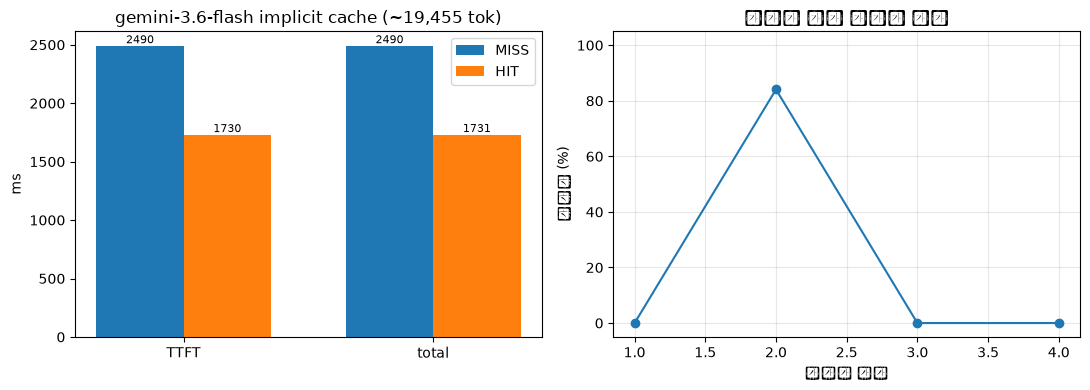

In [9]:
# === 막대그래프 (matplotlib 있으면) ===
try:
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    labels = ["TTFT", "total"]
    miss_ms = [summary["ttft"]["miss"]["mean"] * 1000, summary["total"]["miss"]["mean"] * 1000]
    hit_ms = [summary["ttft"]["hit"]["mean"] * 1000, summary["total"]["hit"]["mean"] * 1000]
    xs, w = range(len(labels)), 0.35
    ax1.bar([x - w / 2 for x in xs], miss_ms, w, label="MISS")
    ax1.bar([x + w / 2 for x in xs], hit_ms, w, label="HIT")
    ax1.set_ylabel("ms")
    ax1.set_xticks(list(xs))
    ax1.set_xticklabels(labels)
    ax1.set_title(f"{MODEL} implicit cache (~{ptoks:,.0f} tok)")
    ax1.legend()
    for i, (mv, hv) in enumerate(zip(miss_ms, hit_ms)):
        ax1.text(i - w / 2, mv, f"{mv:.0f}", ha="center", va="bottom", fontsize=8)
        ax1.text(i + w / 2, hv, f"{hv:.0f}", ha="center", va="bottom", fontsize=8)

    # 워밍업 회차별 적중률 추이 — 암시적 캐싱 고유의 관전 포인트
    rates = [(r["cached"] / r["prompt_tokens"] * 100 if r["prompt_tokens"] else 0) for r in warm_rows]
    ax2.plot(range(1, len(rates) + 1), rates, marker="o")
    ax2.set_xlabel("워밍업 회차")
    ax2.set_ylabel("적중률 (%)")
    ax2.set_title("암시적 캐시 워밍업 추이")
    ax2.set_ylim(-5, 105)
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("시각화 건너뜀:", e)

In [10]:
# === 결과 저장 (4개 노트북 공통 스키마 → 교차 비교용) ===
result = {
    "provider": "google",
    "model": MODEL,
    "cache_mode": "implicit",
    "target_tokens": TARGET_TOKENS,
    "prompt_tokens": ptoks,
    "n_repeat": N_REPEAT,
    "ttft_miss_ms": summary["ttft"]["miss"]["mean"] * 1000,
    "ttft_hit_ms": summary["ttft"]["hit"]["mean"] * 1000,
    "ttft_improve_pct": summary["ttft"]["improve_pct"],
    "total_miss_ms": summary["total"]["miss"]["mean"] * 1000,
    "total_hit_ms": summary["total"]["hit"]["mean"] * 1000,
    "total_improve_pct": summary["total"]["improve_pct"],
    "cached_tokens_hit": avg_cached_hit,
    "cached_tokens_miss": avg_cached_miss,
    "hit_rate": hit_rate,
    "cost_miss_usd": miss_cost,
    "cost_hit_usd": hit_cost,
    "cost_save_pct": save_pct,
    # Gemini 암시적 캐싱 고유 필드
    "gemini_first_hit_at_warmup": first_hit_at,
    "gemini_hit_calls_of_n": n_hit_calls,
    "gemini_warmup_rates": [
        (r["cached"] / r["prompt_tokens"] if r["prompt_tokens"] else 0) for r in warm_rows
    ],
}
out = pathlib.Path("results.json")
out.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"저장: {out.resolve()}")
print(json.dumps(result, indent=2, ensure_ascii=False))

저장: /Users/user/jinsup_space/research/notebooks/kv_cache/gemini36/results.json
{
  "provider": "google",
  "model": "gemini-3.6-flash",
  "cache_mode": "implicit",
  "target_tokens": 20000,
  "prompt_tokens": 19455,
  "n_repeat": 3,
  "ttft_miss_ms": 2490.1051113847643,
  "ttft_hit_ms": 1729.7446663336207,
  "ttft_improve_pct": 30.535275060268518,
  "total_miss_ms": 2490.408597358813,
  "total_hit_ms": 1730.542444003125,
  "total_improve_pct": 30.511706157839292,
  "cached_tokens_hit": 16357,
  "cached_tokens_miss": 0,
  "hit_rate": 0.8407607298894886,
  "cost_miss_usd": 0.005849633333333333,
  "cost_hit_usd": 0.0014217766666666666,
  "cost_save_pct": 75.6946019408624,
  "gemini_first_hit_at_warmup": 2,
  "gemini_hit_calls_of_n": 3,
  "gemini_warmup_rates": [
    0.0,
    0.8407607298894886,
    0.0,
    0.0
  ]
}


## 결과 해석 가이드

- **`cached_content_token_count` 가 `None` 으로 오면 미스**입니다. 이 노트북은 `or 0` 으로 정규화했지만, 실무 코드에서 이 필드를 그냥 더하면 `TypeError` 가 납니다 — 항상 None 을 방어하세요.
- **적중까지 워밍업이 필요합니다.** 위 '워밍업 추이' 표에서 첫 적중 회차를 확인하세요. GPT/Claude 는 2회차부터 잡히지만 암시적 캐싱은 더 걸릴 수 있습니다.
- **적중해도 부분 캐싱**입니다. 프리픽스 전체가 아니라 일부만 잡히는 경우가 많아, 이론적 최대 이득(전량 캐싱)에는 못 미칩니다.
- **보장이 없습니다.** 같은 코드를 다시 돌려도 히트 회차·적중률이 달라집니다. 재현 가능한 벤치마크를 원하면 여러 번 실행해 분포를 보세요.

### 암시적 캐싱으로 히트율을 높이는 방법
- **변하지 않는 큰 내용(문서·지침)을 프롬프트 맨 앞**에, 매번 바뀌는 질문을 맨 뒤에 두세요. 암시적 캐싱도 프리픽스 매칭입니다.
- **최소 토큰 요건**을 넘기세요. 너무 짧은 프롬프트는 아예 캐싱 대상이 아닙니다.
- 요청을 **연속으로** 보내세요. 간격이 벌어지면 evict 됩니다.

### 히트를 보장해야 한다면 — 명시적 캐싱
```python
cache = client.caches.create(
    model=MODEL,
    config=types.CreateCachedContentConfig(contents=[...], ttl="300s"),
)
resp = client.models.generate_content(
    model=MODEL, contents="질문",
    config=types.GenerateContentConfig(cached_content=cache.name),
)
```
명시적 캐싱은 히트가 **보장**되는 대신 캐시 저장 시간에 대한 **스토리지 비용**을 별도로 냅니다.
이 노트북의 주제는 암시적 캐싱이므로 여기서는 대비만 해둡니다.

---

## ⚠️ 이 노트북을 실제로 실행했을 때 관측된 것

20,000 토큰 규모 · 워밍업 4회 · 반복 3회로 실행한 결과:

| 지표 | 값 |
|---|---|
| 첫 적중 회차 | **2회차** |
| 워밍업 적중률 추이 | **[0%, 84.1%, 0%, 0%]** ← 붙었다가 **다시 떨어짐** |
| HIT 구간 적중 | 3/3회 (적중률 84.1%) |
| TTFT 개선 | **+30.5%** |
| 비용 절감 | **75.7%** |

**가장 중요한 관찰**: 워밍업 2회차에 84% 적중했는데 **3·4회차에 다시 0%로 떨어졌습니다.**
동일한 프리픽스를 연속으로 보냈는데도 그렇습니다. 이것이 "암시적 캐싱은 보장되지 않는다"의 실체입니다.

무료 티어 스로틀링 때문에 호출 간 13초 간격이 있었던 점도 영향을 줬을 수 있습니다
(간격이 벌어지면 evict 확률이 올라감). 유료 티어에서 `RPM_LIMIT` 을 올려 간격을 좁히면
적중 패턴이 달라질 수 있으니 비교해 보세요.

**적중률도 84.1%** 로 GPT 계열(99%대)·Claude(99.9%)보다 낮습니다 — 부분 캐싱이기 때문입니다.
따라서 같은 프리픽스라도 **Gemini 암시적 캐싱의 기대 이득이 가장 작고 가장 불확실**합니다.
히트가 반드시 필요한 워크로드라면 명시적 캐싱(`client.caches.create`)을 쓰세요.
